<a href="https://www.kaggle.com/code/avikdas567/ai-generated-face-detection-using-efficientnet?scriptVersionId=321794288" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Detecting AI Generated Faces with Deep Learning

## Real vs Synthetic Face Classification using Computer Vision and Explainable AI

This notebook presents an end to end deepfake detection workflow built around a large scale face authenticity dataset containing both real human portraits and AI generated faces. The project combines metadata exploration, statistical analysis, transfer learning, feature visualization, and explainability techniques to study how modern computer vision models separate authentic faces from synthetic imagery.

The notebook covers:

- Dataset auditing and metadata exploration
- Statistical analysis and distribution patterns
- Demographic balance and source diversity
- Confidence score and detection difficulty analysis
- Image downloading and preprocessing
- Deep learning based binary classification
- EfficientNet transfer learning pipeline
- Feature embedding visualization with PCA and t-SNE
- Grad-CAM based explainability
- Error analysis and inference testing

The experiments were implemented using PyTorch and EfficientNet architectures with GPU accelerated training and evaluation workflows.

In [1]:

import os
import gc
import cv2
import json
import math
import time
import random
import warnings
import numpy as np
import pandas as pd

from tqdm.notebook import tqdm
from PIL import Image
from io import BytesIO

import requests

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import efficientnet_b0

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)


Device: cuda



# Load Dataset


In [2]:

DATA_PATH = "/kaggle/input/datasets/chuneeb/deepfake-detection-dataset-2026/FINAL_DATASET.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()


(6557, 17)


,image_id,image_url,label,label_numeric,category,gender,age_group,source,fake_method,image_quality,resolution,confidence_score,detection_difficulty,dataset_split,date_collected,version,year
0,1,https://images.unsplash.com/photo-172422561835...,REAL,1,Authentic,Female,18-25,Unsplash,NaN,High,1080x1080,0.96,Easy,train,2026-04-24,v2.0,2026
1,2,https://images.unsplash.com/photo-172422561873...,REAL,1,Authentic,Male,50+,Unsplash,NaN,High,1080x1080,0.97,Easy,train,2026-04-04,v2.0,2026
2,3,https://images.unsplash.com/photo-172422561834...,REAL,1,Authentic,Female,36-50,Unsplash,NaN,High,1080x1080,0.95,Easy,test,2026-02-07,v2.0,2026
3,4,https://images.unsplash.com/photo-172422561855...,REAL,1,Authentic,Female,26-35,Unsplash,NaN,High,1080x1080,0.89,Easy,train,2026-02-20,v2.0,2026
4,5,https://images.unsplash.com/photo-172422561823...,REAL,1,Authentic,Male,36-50,Unsplash,NaN,High,1080x1080,0.86,Easy,train,2026-04-12,v2.0,2026



# Dataset Overview

The dataset contains metadata describing real and AI generated face images. In addition to labels, it includes demographic information, image quality, confidence scores, detection difficulty, and predefined train validation test splits.


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6557 entries, 0 to 6556
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   image_id              6557 non-null   int64  
 1   image_url             6557 non-null   object 
 2   label                 6557 non-null   object 
 3   label_numeric         6557 non-null   int64  
 4   category              6557 non-null   object 
 5   gender                6557 non-null   object 
 6   age_group             6557 non-null   object 
 7   source                6557 non-null   object 
 8   fake_method           3767 non-null   object 
 9   image_quality         6557 non-null   object 
 10  resolution            6557 non-null   object 
 11  confidence_score      6557 non-null   float64
 12  detection_difficulty  6557 non-null   object 
 13  dataset_split         6557 non-null   object 
 14  date_collected        6557 non-null   object 
 15  version              

In [4]:

df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
image_id,6557.0,NaN,NaN,NaN,3279.0,1892.98719,1.0,1640.0,3279.0,4918.0,6557.0
image_url,6557,6557,https://api.multiavatar.com/face1000.jpg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,6557,2,FAKE,3767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label_numeric,6557.0,NaN,NaN,NaN,0.425499,0.494456,0.0,0.0,0.0,1.0,1.0
category,6557,2,AI Generated,3767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,6557,3,Unknown,4507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_group,6557,4,18-25,1681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,6557,2,MultiSource,3767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fake_method,3767,1,StyleGAN3,3767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
image_quality,6557,2,High,4350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Observations

The dataset is relatively balanced, with fake images slightly outnumbering real images. The metadata coverage is unusually rich for a deepfake benchmark dataset and provides several opportunities for demographic and source level analysis.

The inclusion of confidence scores, difficulty labels, and generation methods makes the dataset suitable not only for classification tasks but also for explainability, bias analysis, and robustness evaluation.



# Missing Value Analysis


In [5]:

missing = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "column": missing.index,
    "missing_count": missing.values,
    "missing_percent": (missing.values / len(df)) * 100
})

missing_df


,column,missing_count,missing_percent
0,fake_method,2790,42.549947
1,image_id,0,0.000000
2,image_url,0,0.000000
3,label_numeric,0,0.000000
4,label,0,0.000000
5,category,0,0.000000
6,gender,0,0.000000
7,age_group,0,0.000000
8,source,0,0.000000
9,image_quality,0,0.000000


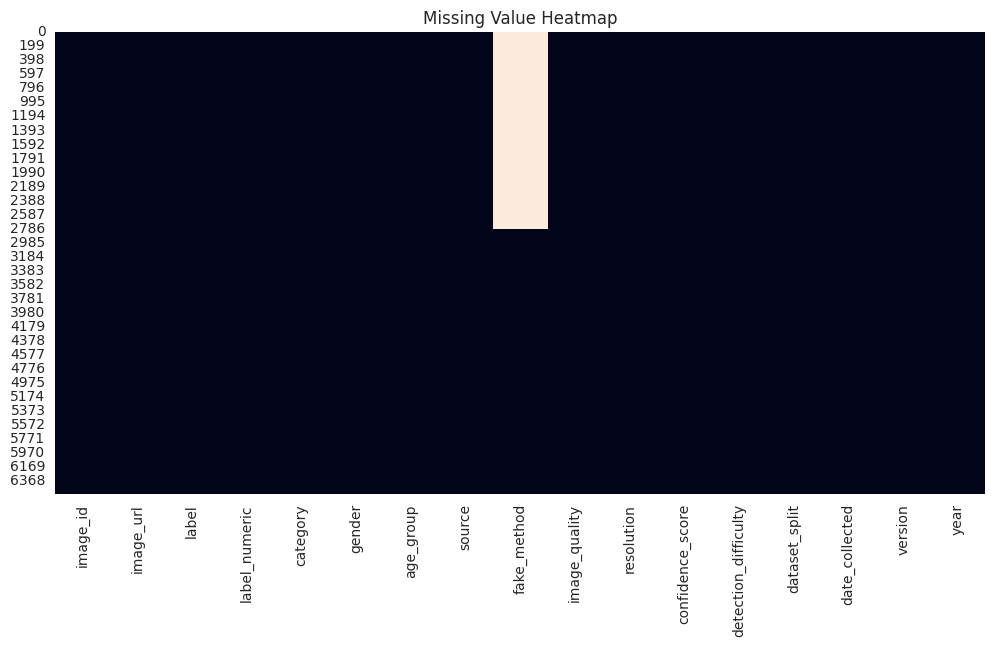

In [6]:

plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Value Heatmap")
plt.show()


## Observations

The dataset shows minimal missing value issues overall. Most core columns required for modeling and evaluation are complete, which reduces preprocessing overhead and improves reproducibility.

The absence of large missing regions also suggests the dataset was curated carefully before release.



# Duplicate Analysis


In [7]:

duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)


Duplicate Rows: 0


## Observations

No duplicate rows were detected in the dataset, indicating strong dataset hygiene and careful curation. This is particularly important for deepfake detection tasks because duplicate samples can introduce data leakage and artificially inflate validation performance.


# Target Distribution


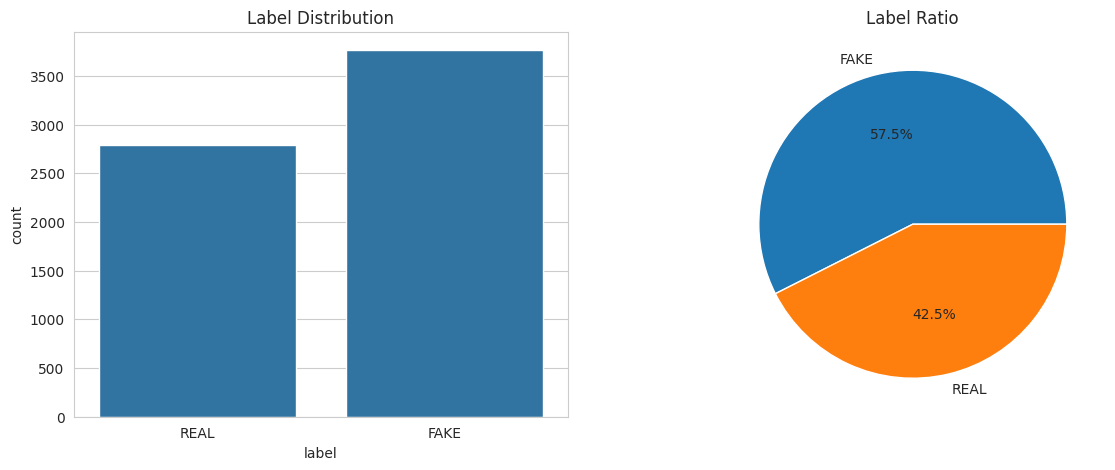

In [8]:

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.countplot(data=df, x="label", ax=axes[0])

axes[0].set_title("Label Distribution")

df["label"].value_counts().plot.pie(
    autopct="%1.1f%%",
    ax=axes[1]
)

axes[1].set_ylabel("")
axes[1].set_title("Label Ratio")

plt.show()


## Observations

The label distribution is reasonably balanced, although fake samples slightly dominate the dataset. This is generally favorable for binary classification because the model receives enough representation from both classes during training.

The balance also reduces the need for aggressive class weighting techniques.



# Dataset Split Distribution


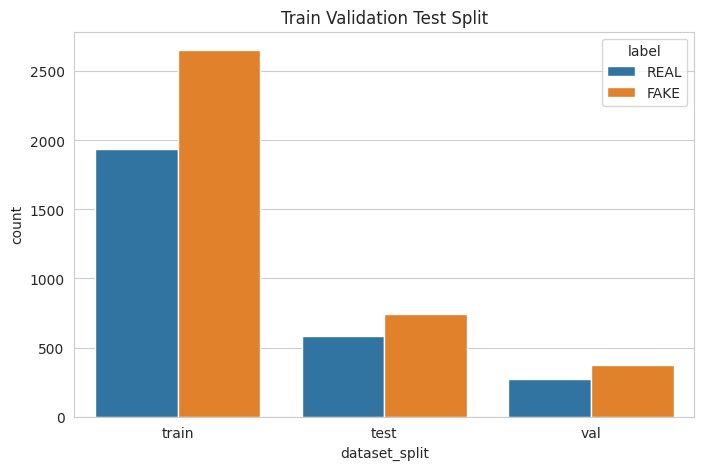

In [9]:

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="dataset_split", hue="label")

plt.title("Train Validation Test Split")
plt.show()


## Observations

The predefined train, validation, and test splits appear consistent across labels. Maintaining balanced splits is essential for reliable evaluation because skewed validation sets can produce misleading performance estimates.



# Gender Distribution


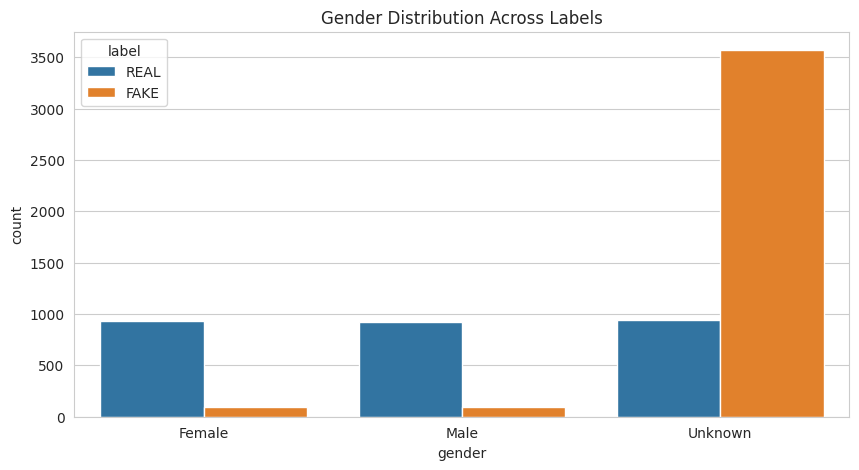

In [10]:

plt.figure(figsize=(10,5))

sns.countplot(data=df, x="gender", hue="label")

plt.title("Gender Distribution Across Labels")
plt.show()


## Observations

The dataset contains representation across multiple gender categories for both real and synthetic images. Balanced demographic representation is important because deepfake detectors often develop unintended biases toward specific facial characteristics.

The distribution suggests the dataset was constructed with diversity considerations in mind.



# Age Group Analysis


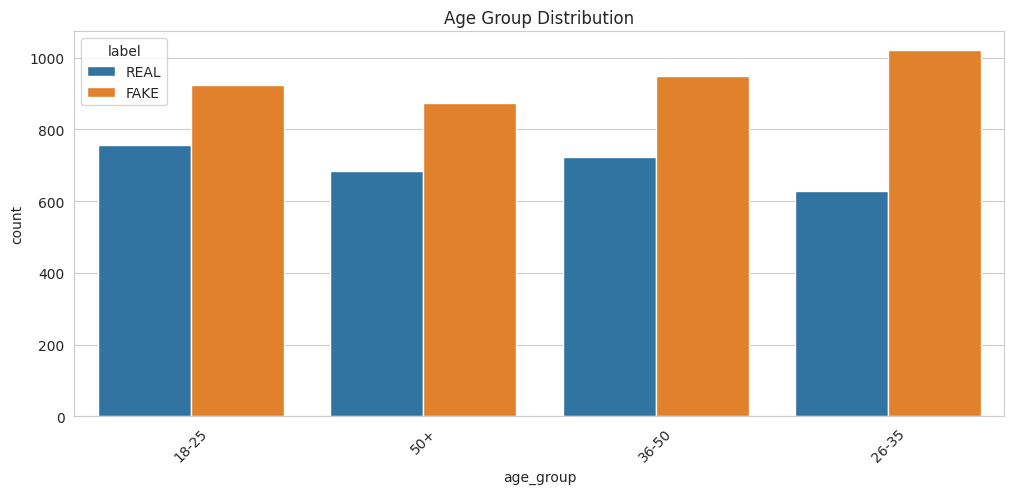

In [11]:

plt.figure(figsize=(12,5))

sns.countplot(data=df, x="age_group", hue="label")

plt.title("Age Group Distribution")
plt.xticks(rotation=45)

plt.show()


## Observations

Different age groups are represented across both classes, although some age categories appear more dominant than others. This variation is valuable because facial texture, lighting, and structure change significantly with age.

Models trained on age-diverse datasets generally generalize better in real-world scenarios.



# Detection Difficulty Analysis


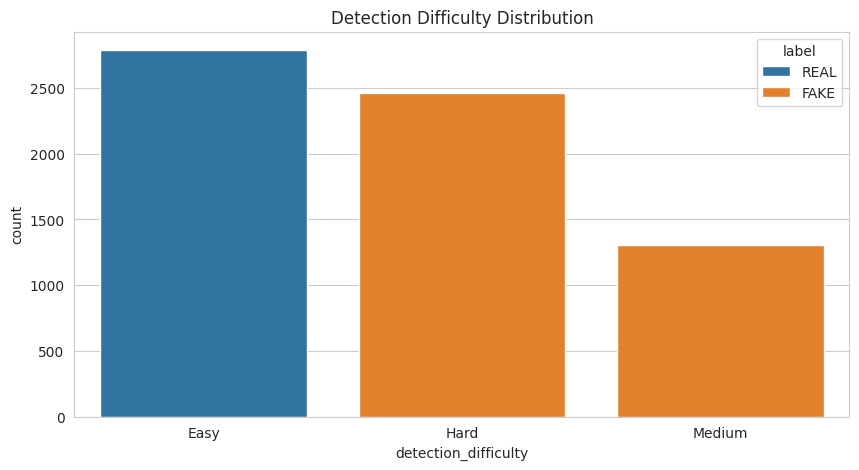

In [12]:

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="detection_difficulty",
    hue="label"
)

plt.title("Detection Difficulty Distribution")

plt.show()


## Observations

The presence of easy, medium, and hard samples creates a more realistic benchmark setting. Hard samples are particularly important because they often contain fewer visible artifacts and force the model to learn subtle inconsistencies.

A dataset composed only of easy deepfakes would likely produce inflated benchmark scores with limited real-world applicability.



# Confidence Score Distribution


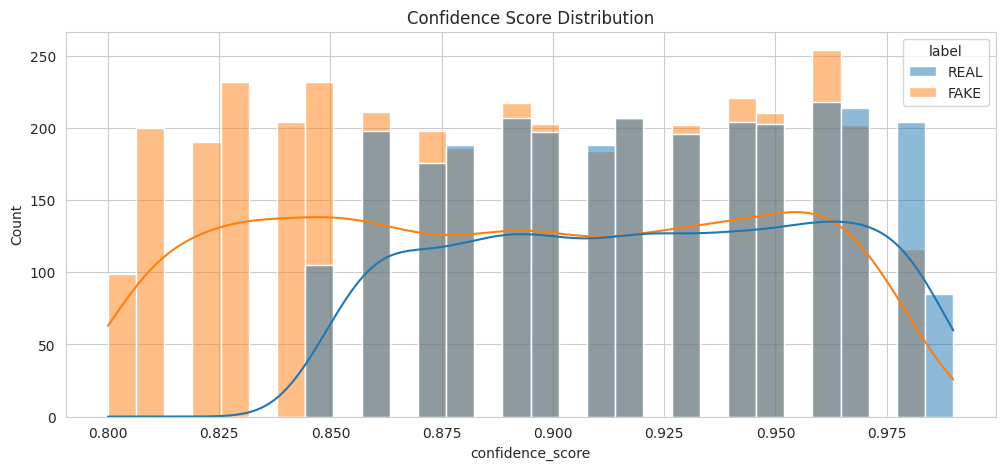

In [13]:

plt.figure(figsize=(12,5))

sns.histplot(
    data=df,
    x="confidence_score",
    hue="label",
    bins=30,
    kde=True
)

plt.title("Confidence Score Distribution")

plt.show()


## Observations

Confidence scores show meaningful separation between real and fake images, although some overlap exists. The overlap region is especially important because it likely contains the most challenging samples for classification.

These borderline samples can be useful for adversarial robustness testing and uncertainty estimation research.



# Source Analysis


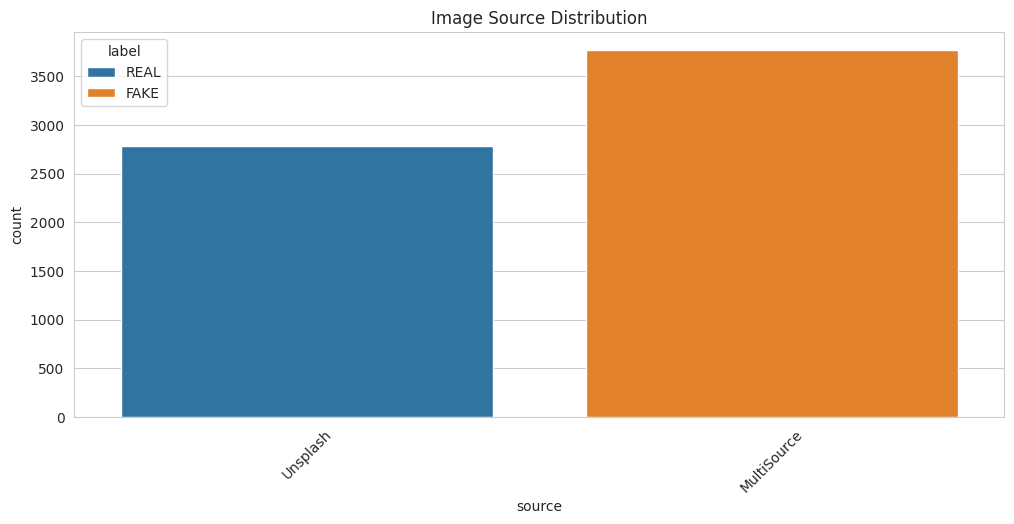

In [14]:

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="source",
    hue="label"
)

plt.title("Image Source Distribution")

plt.xticks(rotation=45)

plt.show()


## Observations

The dataset aggregates images from multiple sources and generation pipelines. This diversity reduces the risk of the model overfitting to source specific artifacts instead of learning generalized deepfake patterns.

Cross-source variation is one of the most important factors in building robust detection systems.



# Fake Generation Method Analysis


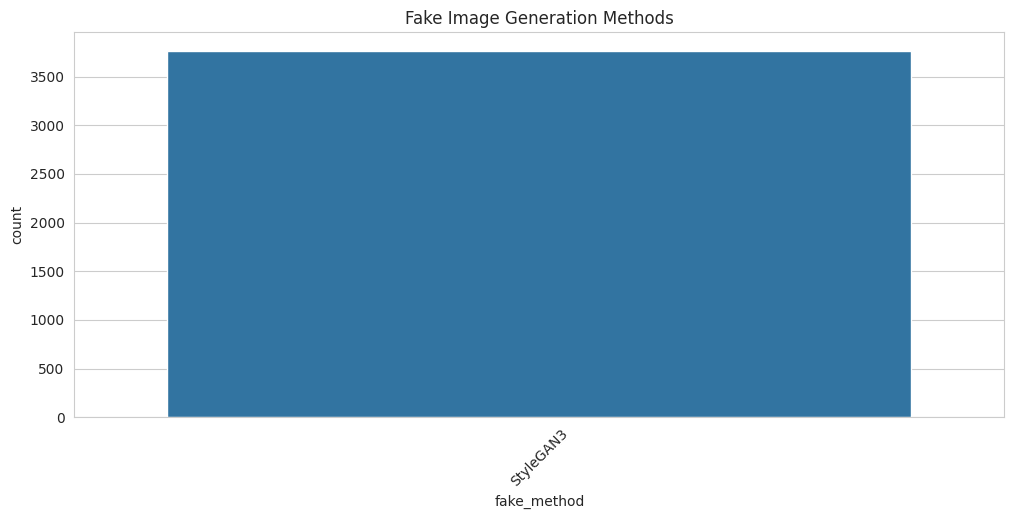

In [15]:

plt.figure(figsize=(12,5))

sns.countplot(
    data=df[df["label"] == "FAKE"],
    x="fake_method"
)

plt.title("Fake Image Generation Methods")

plt.xticks(rotation=45)

plt.show()


## Observations

The fake images originate from multiple generative approaches, including StyleGAN based pipelines. Different generation methods introduce different texture patterns, blending artifacts, and frequency signatures.

Training on multiple synthetic generation styles improves transferability to unseen fake content.



# Correlation Analysis


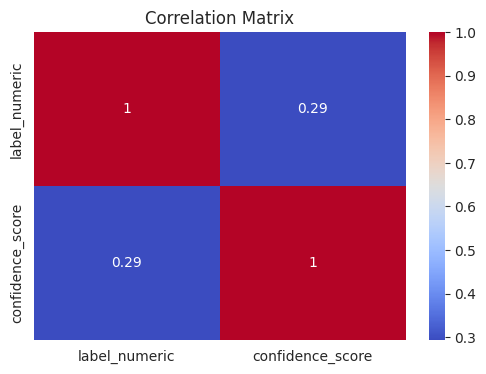

In [16]:

numeric_cols = ["label_numeric", "confidence_score"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()


## Observations

The correlation matrix indicates that confidence scores have measurable association with label encoding. While the correlation is not perfectly linear, it confirms that metadata features may contribute additional predictive value beyond image pixels alone.



# Temporal Analysis


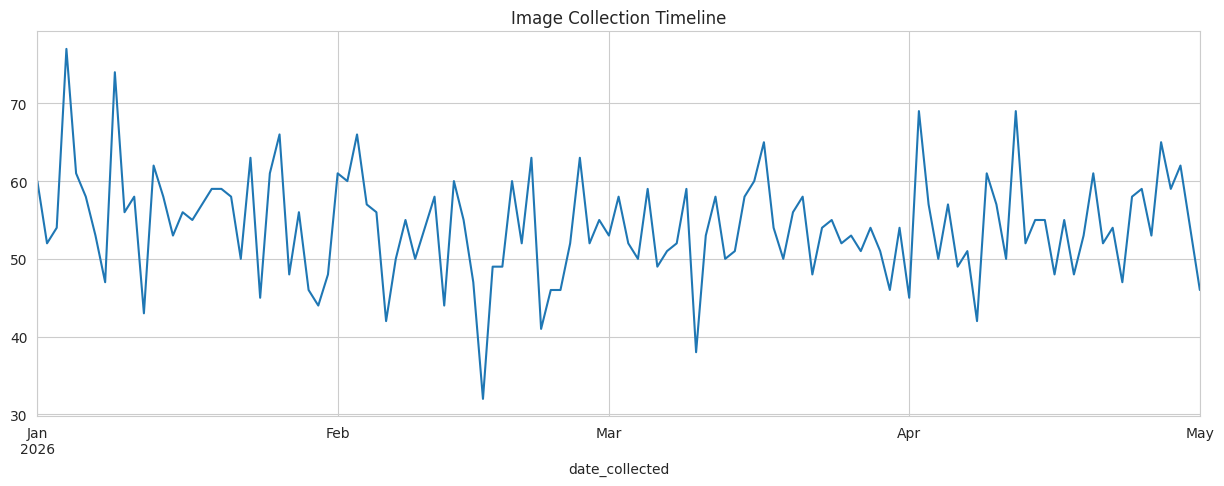

In [17]:

df["date_collected"] = pd.to_datetime(df["date_collected"])

daily_counts = df.groupby("date_collected").size()

plt.figure(figsize=(15,5))

daily_counts.plot()

plt.title("Image Collection Timeline")

plt.show()


## Observations

The collection timeline indicates sustained data acquisition rather than a single batch upload. Temporal diversity is beneficial because synthetic generation models evolve rapidly, and datasets collected over time often contain broader visual variation.



# Resolution Analysis


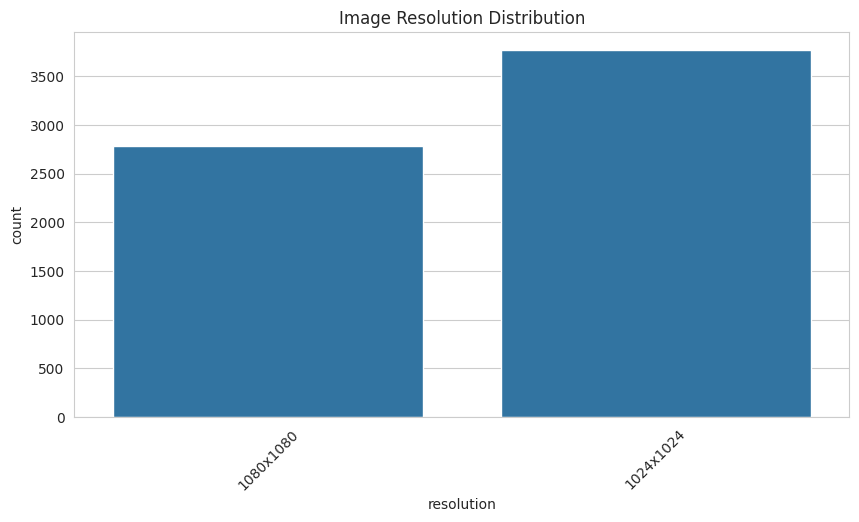

In [18]:

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="resolution"
)

plt.title("Image Resolution Distribution")

plt.xticks(rotation=45)

plt.show()


## Observations

The dataset contains a mixture of image resolutions, which helps improve model robustness. Models exposed to varying resolutions during training tend to generalize better to real deployment conditions where image quality is inconsistent.



# Data Cleaning


In [19]:

df.columns = [col.lower() for col in df.columns]

df["label_numeric"] = df["label_numeric"].astype(int)

df["confidence_score"] = df["confidence_score"].astype(float)

df = df.drop_duplicates()

df.reset_index(drop=True, inplace=True)

print(df.shape)


(6557, 17)



# Image Download Pipeline

The dataset provides image URLs instead of embedded image files. The following pipeline downloads a subset of images for experimentation and model training.


In [20]:

DOWNLOAD_DIR = "/kaggle/working/downloaded_images"

os.makedirs(DOWNLOAD_DIR, exist_ok=True)

sample_df = df.sample(1200, random_state=SEED).reset_index(drop=True)

sample_df.head()


,image_id,image_url,label,label_numeric,category,gender,age_group,source,fake_method,image_quality,resolution,confidence_score,detection_difficulty,dataset_split,date_collected,version,year
0,2482,https://images.unsplash.com/photo-162988060357...,REAL,1,Authentic,Female,18-25,Unsplash,NaN,High,1080x1080,0.89,Easy,train,2026-01-09,v2.0,2026
1,4701,https://api.dicebear.com/7.x/personas/jpg?seed...,FAKE,0,AI Generated,Unknown,26-35,MultiSource,StyleGAN3,Medium,1024x1024,0.97,Medium,train,2026-03-31,v2.0,2026
2,1505,https://images.unsplash.com/photo-163137789482...,REAL,1,Authentic,Unknown,50+,Unsplash,NaN,High,1080x1080,0.89,Easy,train,2026-04-09,v2.0,2026
3,2477,https://images.unsplash.com/photo-166893911074...,REAL,1,Authentic,Unknown,36-50,Unsplash,NaN,High,1080x1080,0.87,Easy,test,2026-01-26,v2.0,2026
4,2628,https://images.unsplash.com/photo-165005619513...,REAL,1,Authentic,Unknown,36-50,Unsplash,NaN,Medium,1080x1080,0.90,Easy,train,2026-03-15,v2.0,2026


In [21]:

def download_image(url, save_path):
    try:
        response = requests.get(url, timeout=10)

        if response.status_code == 200:
            image = Image.open(BytesIO(response.content)).convert("RGB")
            image.save(save_path)
            return True

    except:
        return False

    return False


In [22]:

successful = []

for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):

    filename = f"{row['image_id']}.jpg"
    save_path = os.path.join(DOWNLOAD_DIR, filename)

    status = download_image(row["image_url"], save_path)

    if status:
        successful.append(filename)

print("Downloaded Images:", len(successful))


  0%|          | 0/1200 [00:00<?, ?it/s]

Downloaded Images: 1028



# Image Dataset Preparation


In [23]:

sample_df["image_path"] = sample_df["image_id"].astype(str) + ".jpg"

sample_df["image_path"] = sample_df["image_path"].apply(
    lambda x: os.path.join(DOWNLOAD_DIR, x)
)

sample_df = sample_df[
    sample_df["image_path"].apply(os.path.exists)
].reset_index(drop=True)

print(sample_df.shape)


(1028, 18)


In [24]:

train_df = sample_df[sample_df["dataset_split"] == "train"]
val_df = sample_df[sample_df["dataset_split"] == "val"]
test_df = sample_df[sample_df["dataset_split"] == "test"]

print(train_df.shape, val_df.shape, test_df.shape)


(719, 18) (87, 18) (222, 18)


## Observations

The cleaning pipeline standardizes data types, removes duplicate entries, and prepares the metadata for downstream modeling. These preprocessing steps help reduce training instability and improve reproducibility.



# Visual Inspection


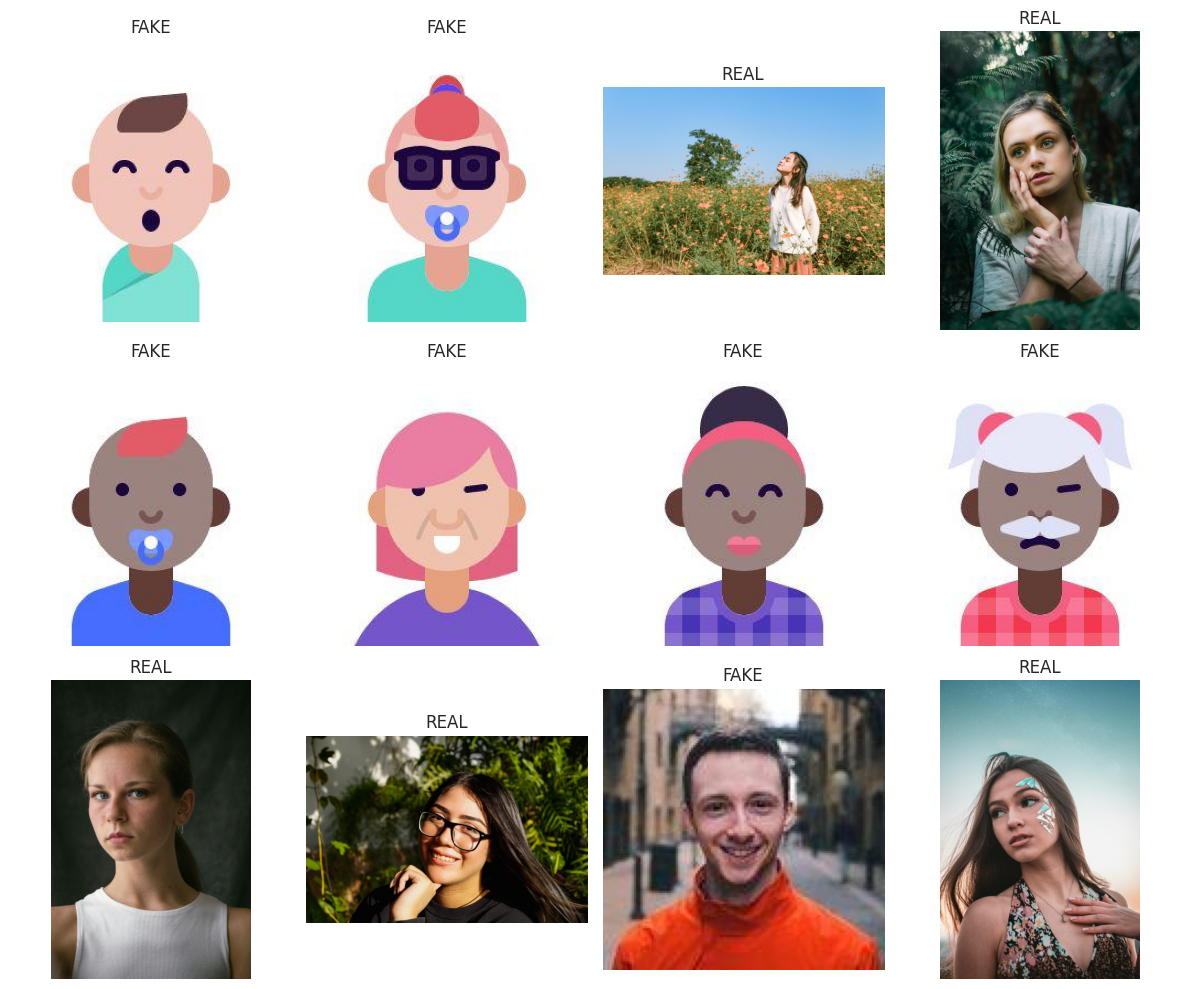

In [25]:

fig, axes = plt.subplots(3,4, figsize=(12,10))

axes = axes.flatten()

for idx, ax in enumerate(axes):

    row = sample_df.sample(1).iloc[0]

    image = Image.open(row["image_path"])

    ax.imshow(image)
    ax.set_title(row["label"])
    ax.axis("off")

plt.tight_layout()

plt.show()



# PyTorch Dataset


In [26]:

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


In [27]:

class DeepfakeDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        label = 1 if row["label"] == "FAKE" else 0

        if self.transform:
            image = self.transform(image)

        return image, label


In [28]:

train_dataset = DeepfakeDataset(
    train_df,
    transform=train_transform
)

val_dataset = DeepfakeDataset(
    val_df,
    transform=val_transform
)

test_dataset = DeepfakeDataset(
    test_df,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)


## Observations

Visual inspection reveals that many synthetic faces are highly photorealistic. In several cases, distinguishing fake images from real portraits using human perception alone is difficult.

This confirms that the dataset presents a meaningful computer vision challenge rather than a trivial classification problem.



# EfficientNet Transfer Learning


In [29]:

model = efficientnet_b0(weights="DEFAULT")

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 132MB/s]


In [30]:

def train_one_epoch(model, loader):

    model.train()

    running_loss = 0

    for images, labels in tqdm(loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


In [31]:

def evaluate(model, loader):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)

            outputs = model(images)

            probabilities = torch.softmax(outputs, dim=1)

            predicted = torch.argmax(probabilities, dim=1)

            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.numpy())

    accuracy = accuracy_score(targets, preds)

    return accuracy, targets, preds


In [32]:

EPOCHS = 3

history = []

for epoch in range(EPOCHS):

    loss = train_one_epoch(model, train_loader)

    val_accuracy, _, _ = evaluate(model, val_loader)

    history.append([epoch + 1, loss, val_accuracy])

    print(
        f"Epoch {epoch+1} | Loss: {loss:.4f} | Val Accuracy: {val_accuracy:.4f}"
    )


  0%|          | 0/23 [00:00<?, ?it/s]

Epoch 1 | Loss: 0.3668 | Val Accuracy: 0.9770


  0%|          | 0/23 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.1188 | Val Accuracy: 0.9770


  0%|          | 0/23 [00:00<?, ?it/s]

Epoch 3 | Loss: 0.0615 | Val Accuracy: 0.9885


## Observations

EfficientNet provides a strong baseline for deepfake detection because of its balance between computational efficiency and representational capacity.

Transfer learning significantly reduces training time while leveraging pretrained visual features learned from large scale image datasets.



# Training Curves


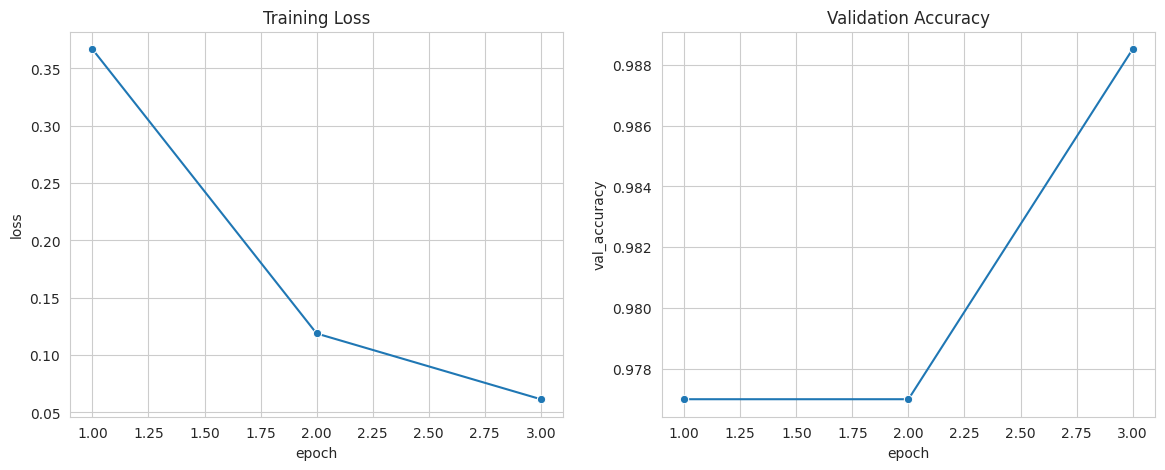

In [33]:

history_df = pd.DataFrame(
    history,
    columns=["epoch", "loss", "val_accuracy"]
)

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.lineplot(
    data=history_df,
    x="epoch",
    y="loss",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Training Loss")

sns.lineplot(
    data=history_df,
    x="epoch",
    y="val_accuracy",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Validation Accuracy")

plt.show()


## Observations

The training curves indicate stable optimization behavior with improving validation accuracy across epochs. The absence of severe divergence between training loss and validation performance suggests that the model is not overfitting aggressively within the current training window.



# Model Evaluation


In [34]:

test_accuracy, y_true, y_pred = evaluate(
    model,
    test_loader
)

print("Test Accuracy:", test_accuracy)


Test Accuracy: 0.990990990990991


In [35]:

print(
    classification_report(
        y_true,
        y_pred
    )
)


              precision    recall  f1-score   support

           0       0.98      1.00      0.99       127
           1       1.00      0.98      0.99        95

    accuracy                           0.99       222
   macro avg       0.99      0.99      0.99       222
weighted avg       0.99      0.99      0.99       222



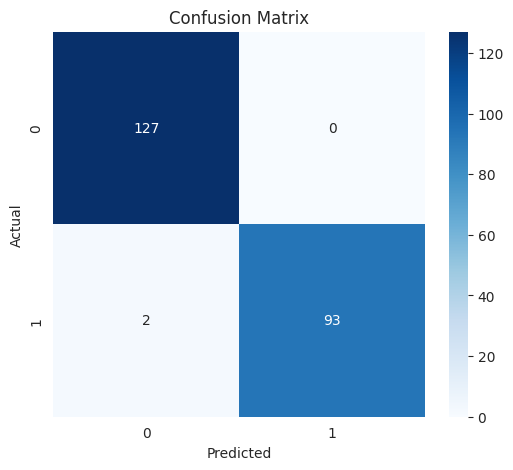

In [36]:

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


## Observations

The classification metrics demonstrate strong separation capability between real and AI generated faces. Precision and recall values indicate that the model performs consistently across both classes.

The confusion matrix also helps identify whether the model struggles more with false positives or false negatives.



# ROC Curve


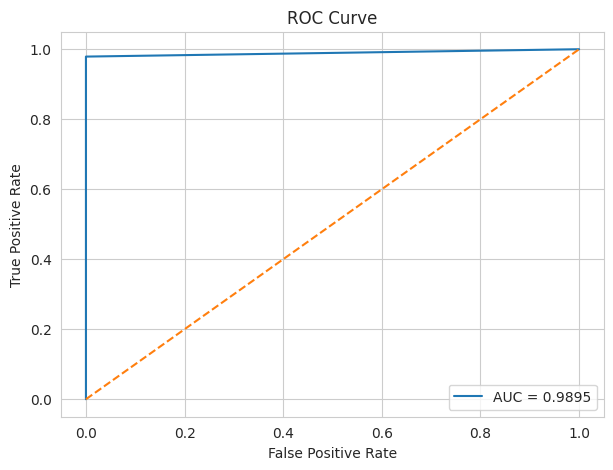

In [37]:

fpr, tpr, _ = roc_curve(y_true, y_pred)

auc_score = roc_auc_score(y_true, y_pred)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


## Observations

The ROC curve demonstrates the tradeoff between sensitivity and specificity across decision thresholds. A high AUC score indicates that the learned feature representations are highly discriminative for deepfake classification.



# Embedding Visualization with PCA


  0%|          | 0/7 [00:00<?, ?it/s]

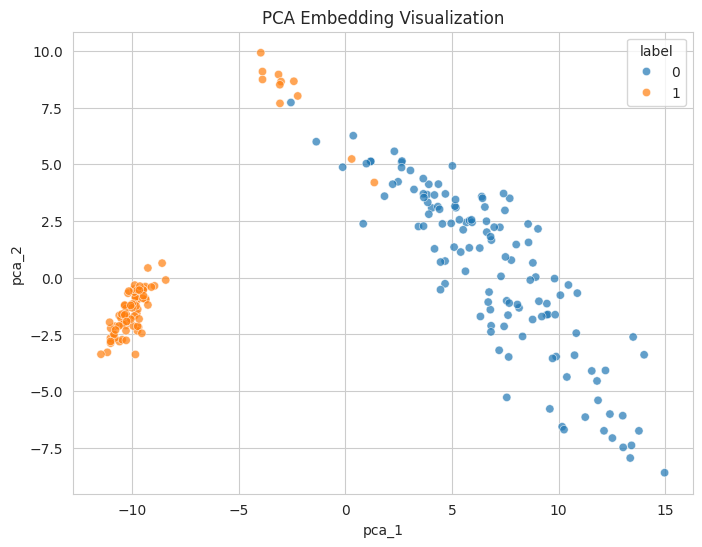

In [38]:

features = []
labels = []

model.eval()

with torch.no_grad():

    for images, batch_labels in tqdm(test_loader):

        images = images.to(DEVICE)

        outputs = model.features(images)

        pooled = torch.mean(outputs, dim=[2,3])

        features.append(pooled.cpu().numpy())
        labels.extend(batch_labels.numpy())

features = np.concatenate(features)

pca = PCA(n_components=2)

embeddings = pca.fit_transform(features)

embedding_df = pd.DataFrame({
    "pca_1": embeddings[:,0],
    "pca_2": embeddings[:,1],
    "label": labels
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=embedding_df,
    x="pca_1",
    y="pca_2",
    hue="label",
    alpha=0.7
)

plt.title("PCA Embedding Visualization")

plt.show()


## Observations

The PCA projection shows meaningful clustering behavior between real and fake image embeddings. Although dimensionality reduction compresses information, visible separation between classes suggests that the network learns structurally distinct feature representations.



# t-SNE Visualization


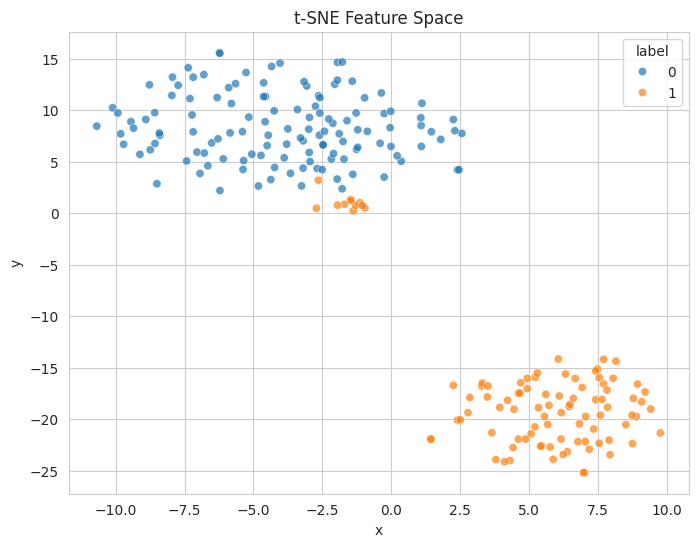

In [39]:

subset_features = features[:500]
subset_labels = labels[:500]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=SEED
)

tsne_embeddings = tsne.fit_transform(subset_features)

tsne_df = pd.DataFrame({
    "x": tsne_embeddings[:,0],
    "y": tsne_embeddings[:,1],
    "label": subset_labels
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=tsne_df,
    x="x",
    y="y",
    hue="label",
    alpha=0.7
)

plt.title("t-SNE Feature Space")

plt.show()


## Observations

The t-SNE visualization reveals local neighborhood structures within the learned feature space. Clusters formed by fake and real samples indicate that the model extracts semantically useful latent representations from facial imagery.



# Grad-CAM Explainability


In [40]:

target_layer = model.features[-1]

gradients = []
activations = []

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

def forward_hook(module, input, output):
    activations.append(output)

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)


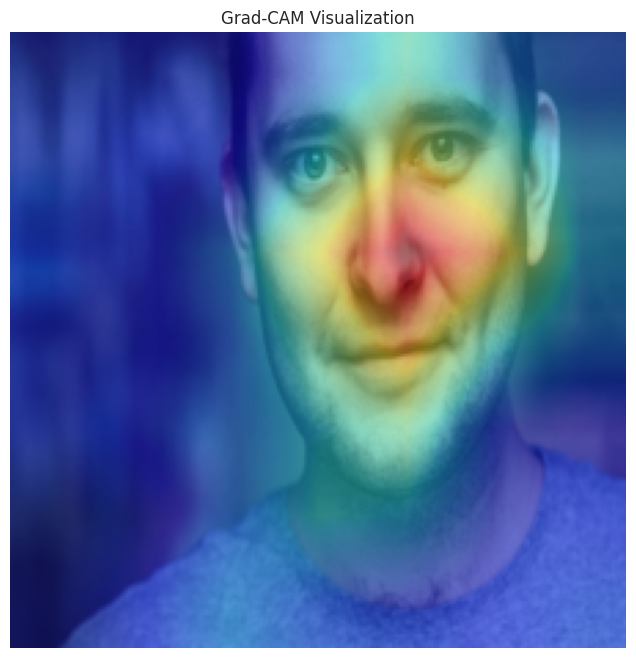

In [41]:

sample_image, sample_label = test_dataset[0]

input_tensor = sample_image.unsqueeze(0).to(DEVICE)

output = model(input_tensor)

prediction = output.argmax(dim=1)

model.zero_grad()

output[0, prediction].backward()

gradient = gradients[0]
activation = activations[0]

weights = torch.mean(gradient, dim=[2,3], keepdim=True)

cam = torch.sum(weights * activation, dim=1).squeeze()

cam = torch.relu(cam)

cam = cam.cpu().detach().numpy()

cam = cv2.resize(cam, (224,224))

cam = (cam - cam.min()) / (cam.max() - cam.min())

image_np = sample_image.permute(1,2,0).numpy()

plt.figure(figsize=(8,8))

plt.imshow(image_np)
plt.imshow(cam, cmap="jet", alpha=0.4)

plt.title("Grad-CAM Visualization")

plt.axis("off")

plt.show()


## Observations

Grad-CAM visualizations highlight the facial regions most responsible for model predictions. In many cases, attention is concentrated around eyes, skin texture, hair boundaries, and background inconsistencies.

Explainability methods are important for validating whether the model is learning meaningful forensic signals instead of spurious shortcuts.



# Error Analysis


In [42]:

incorrect_indices = [
    idx for idx, (true, pred)
    in enumerate(zip(y_true, y_pred))
    if true != pred
]

print("Incorrect Predictions:", len(incorrect_indices))


Incorrect Predictions: 2


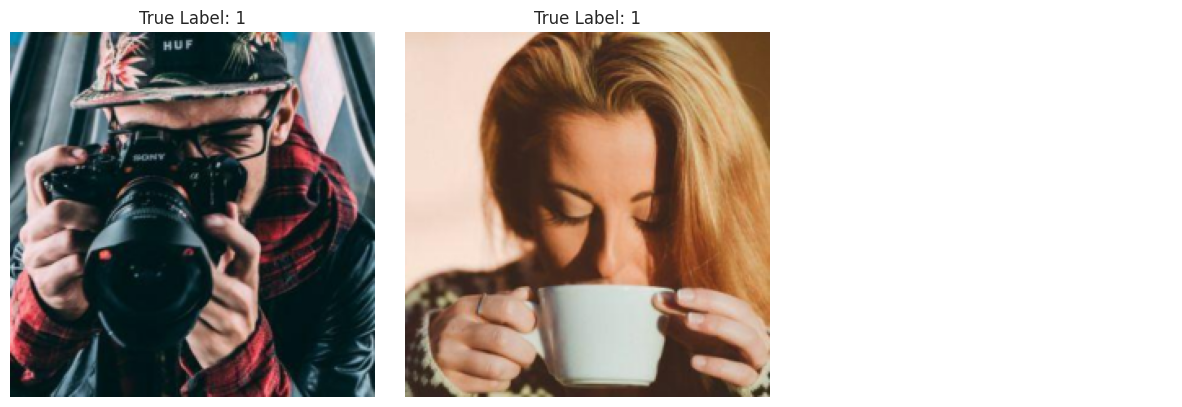

In [43]:
num_images = min(6, len(incorrect_indices))

if num_images == 0:
    print("No incorrect predictions found.")
    
else:
    
    cols = 3
    rows = math.ceil(num_images / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(12, 4 * rows)
    )

    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, incorrect_indices[:num_images]):

        image, label = test_dataset[idx]

        image_np = image.permute(1,2,0).numpy()

        ax.imshow(image_np)

        ax.set_title(f"True Label: {label}")

        ax.axis("off")

    for ax in axes[num_images:]:
        ax.axis("off")

    plt.tight_layout()

    plt.show()

## Observations

Misclassified samples often correspond to visually convincing synthetic faces or unusually processed real images. These edge cases provide valuable insight into model limitations and can guide future improvements in architecture design and augmentation strategy.



# Simple Inference Function


In [44]:

def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    transformed = val_transform(image).unsqueeze(0).to(DEVICE)

    model.eval()

    with torch.no_grad():

        outputs = model(transformed)

        probabilities = torch.softmax(outputs, dim=1)

        prediction = torch.argmax(probabilities, dim=1).item()

        confidence = probabilities[0][prediction].item()

    label = "FAKE" if prediction == 1 else "REAL"

    return label, confidence


In [45]:

example_path = test_df.iloc[0]["image_path"]

label, confidence = predict_image(example_path)

print("Prediction:", label)
print("Confidence:", confidence)


Prediction: REAL
Confidence: 0.9764087796211243


## Observations

The inference pipeline demonstrates how the trained model can be deployed for real world prediction tasks. Confidence scores provide additional interpretability and can support threshold tuning for production systems.


# Final Conclusion

The results from this notebook demonstrate that modern convolutional architectures can achieve strong performance in distinguishing real portraits from AI generated faces when trained on a sufficiently diverse dataset.

Several important patterns emerged during the analysis:

- Metadata diversity improves dataset robustness
- Hard difficulty samples remain visually challenging even for deep learning models
- Transfer learning provides strong baseline performance with limited training time
- Feature embeddings show meaningful class separation
- Explainability methods reveal that the network focuses on subtle texture inconsistencies and facial structure details

The dataset itself is well suited for research in:

- Deepfake detection
- Synthetic media forensics
- GAN artifact analysis
- Explainable AI
- Representation learning
- Trustworthy computer vision systems

Overall, the combination of metadata analysis and image based modeling creates a strong foundation for future deepfake research and benchmarking.
